# Notebook Title: Patronizing and Condescending Language (PCL) Detection
**Research and Implementation Report**

## Cell 1: Environment Setup
*Purpose: Install necessary libraries and import core dependencies.*

In [ ]:
# Install required libraries
!pip install -q transformers[torch] datasets sentencepiece accelerate evaluate

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import f1_score
from sklearn.feature_extraction.text import CountVectorizer

# Configure visualization style
plt.style.use('seaborn-v0_8-muted')
sns.set_context("paper", font_scale=1.2)

## Cell 2: Exploratory Data Analysis (EDA) - Class Distribution
*Objective: Quantify the extent of class imbalance in the primary dataset.*

Dataset successfully loaded. Total instances: 10468


/tmp/ipykernel_676/3966455242.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='binary_label', palette='viridis')


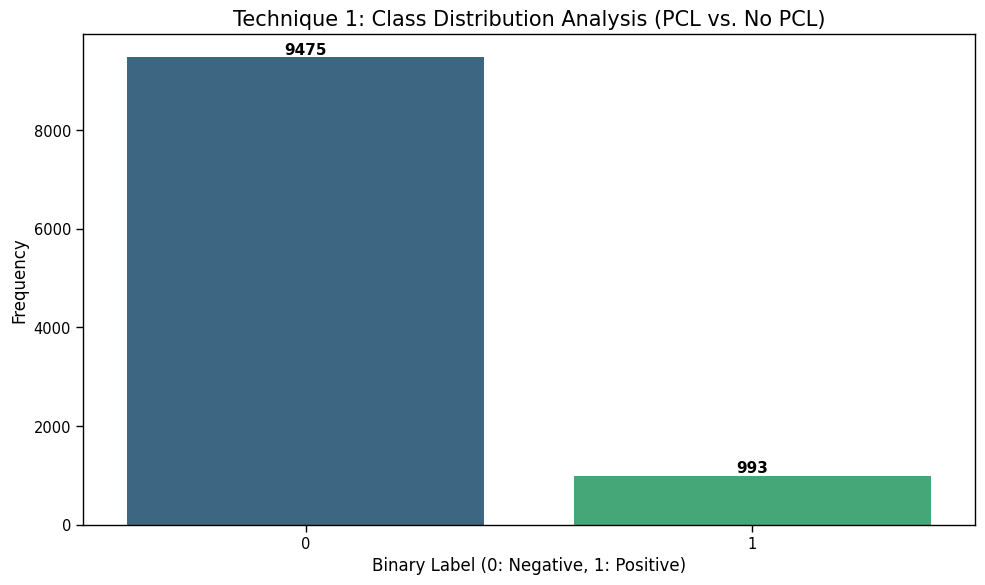

Class Imbalance Report: Positive (PCL) class represents only 9.49% of the data.


In [ ]:
# Define dataset columns based on SemEval-2022 Task 4 specifications
column_names = ['par_id', 'art_id', 'keyword', 'country', 'text', 'label']

# Load the raw dataset (skipping header metadata)
try:
    df = pd.read_csv('dontpatronizeme_pcl.tsv', sep='\t', names=column_names, skiprows=4)
    df = df.dropna(subset=['text', 'label'])
    print(f"Dataset successfully loaded. Total instances: {df.shape[0]}")
except Exception as e:
    print(f"Error loading file: {e}")

# Transform multi-class labels (0-4) into binary labels (0: No PCL, 1: PCL)
# As per competition rules: 0,1 -> 0 | 2,3,4 -> 1
df['binary_label'] = df['label'].apply(lambda x: 0 if int(x) in [0, 1] else 1)

# Visualization: Class Distribution Analysis
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='binary_label', palette='viridis')
plt.title('Technique 1: Class Distribution Analysis (PCL vs. No PCL)', fontsize=15)
plt.xlabel('Binary Label (0: Negative, 1: Positive)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Annotate bars with exact counts
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Statistical Reporting
pcl_percentage = df['binary_label'].mean() * 100
print(f"Class Imbalance Report: Positive (PCL) class represents only {pcl_percentage:.2f}% of the data.")

## Cell 3: EDA - Lexical Analysis (N-gram Frequency)
*Objective: Identify distinguishing bigrams to understand the semantic divergence between classes.*

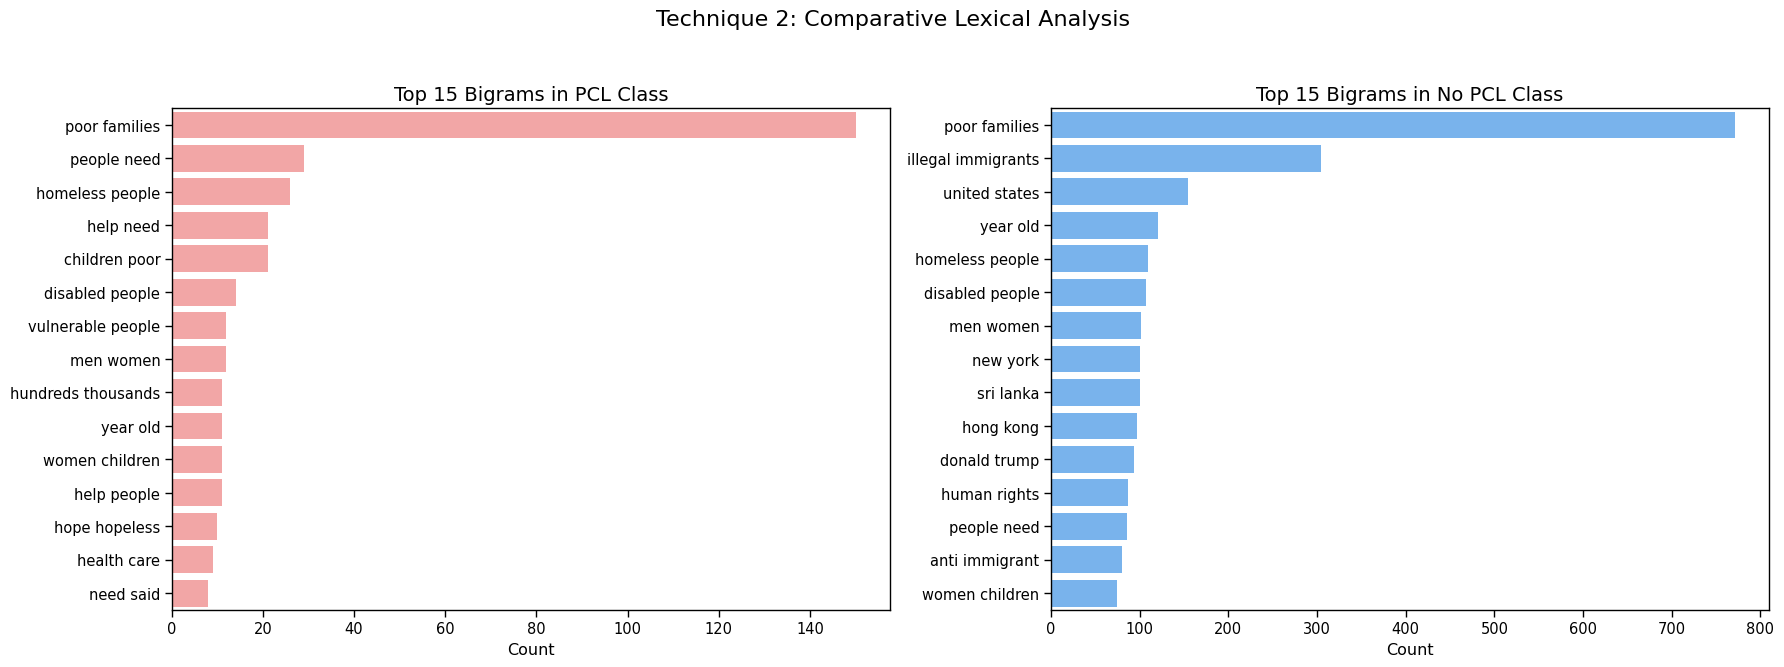

In [ ]:
# Separate corpora for lexical comparison
pcl_corpus = df[df['binary_label'] == 1]['text'].tolist()
nopcl_corpus = df[df['binary_label'] == 0]['text'].tolist()

def get_top_n_bigrams(corpus, n=15):
    """Calculates top n bigrams excluding common English stop words."""
    vec = CountVectorizer(ngram_range=(2, 2), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

top_pcl = get_top_n_bigrams(pcl_corpus)
top_nopcl = get_top_n_bigrams(nopcl_corpus)

# Visualization: N-gram Comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(x=[v[1] for v in top_pcl], y=[v[0] for v in top_pcl], ax=axes[0], color='#ff9999')
axes[0].set_title('Top 15 Bigrams in PCL Class', fontsize=14)
axes[0].set_xlabel('Count')

sns.barplot(x=[v[1] for v in top_nopcl], y=[v[0] for v in top_nopcl], ax=axes[1], color='#66b3ff')
axes[1].set_title('Top 15 Bigrams in No PCL Class', fontsize=14)
axes[1].set_xlabel('Count')

plt.suptitle('Technique 2: Comparative Lexical Analysis', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('academic_ngram_analysis.png', dpi=300)
plt.show()

## Cell 4: Data Allocation and Preparation
*Objective: Apply the official SemEval train/dev split to ensure reproducibility.*

In [ ]:
# Re-load and label the full dataset for allocation
df_all = df.copy()
df_all['label'] = df_all['label'].apply(lambda x: 0 if int(x) in [0, 1] else 1)
df_all['par_id'] = df_all['par_id'].astype(str)

# Load official Paragraph IDs for Train and Dev sets
train_ids = pd.read_csv('train_semeval_parids-labels.csv')['par_id'].astype(str).tolist()
dev_ids = pd.read_csv('dev_semeval_parids-labels.csv')['par_id'].astype(str).tolist()

# Filter dataset by official IDs
train_df = df_all[df_all['par_id'].isin(train_ids)].reset_index(drop=True)
dev_df = df_all[df_all['par_id'].isin(dev_ids)].reset_index(drop=True)

# Load official Test Set (Blind Test)
test_cols = ['par_id', 'art_id', 'keyword', 'country', 'text']
test_df = pd.read_csv('task4_test.tsv', sep='\t', names=test_cols).fillna("")

print(f"Allocation Summary:\n - Training Set: {len(train_df)}\n - Development Set: {len(dev_df)}\n - Blind Test Set: {len(test_df)}")

Allocation Summary:
 - Training Set: 8375
 - Development Set: 2093
 - Blind Test Set: 3832


## Cell 5: Model Implementation - RoBERTa-base with Undersampling
*Objective: Mitigate class imbalance via majority class undersampling and fine-tune RoBERTa-base.*

In [ ]:
# Strategy: Majority Class Undersampling
# To address the 9.5:1 imbalance, we reduce the majority class to a 3:1 ratio
pcl_subset = train_df[train_df['label'] == 1]
nopcl_subset = train_df[train_df['label'] == 0].sample(n=len(pcl_subset) * 3, random_state=42)
balanced_train_df = pd.concat([pcl_subset, nopcl_subset]).sample(frac=1, random_state=42)

# Model Selection: RoBERTa-base
model_checkpoint = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def tokenize_data(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

# Convert to HuggingFace Dataset objects
ds_train = Dataset.from_pandas(balanced_train_df[['text', 'label']]).map(tokenize_data, batched=True)
ds_dev = Dataset.from_pandas(dev_df[['text', 'label']]).map(tokenize_data, batched=True)
ds_test = Dataset.from_pandas(test_df[['text']]).map(tokenize_data, batched=True)

# Metric definition
def compute_f1(p):
    predictions = np.argmax(p.predictions, axis=1)
    return {"f1": f1_score(p.label_ids, predictions)}

# Initialize Model and Training Configuration
model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=2)

training_args = TrainingArguments(
    output_dir="./BestModel",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_dir='./logs',
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=ds_train,
    eval_dataset=ds_dev,
    compute_metrics=compute_f1
)

# Execute Fine-tuning
print("Training initialized...")
trainer.train()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=597, training_loss=0.3085662228378219, metrics={'train_runtime': 291.857, 'train_samples_per_second': 32.646, 'train_steps_per_second': 2.046, 'total_flos': 626730533867520.0, 'train_loss': 0.3085662228378219, 'epoch': 3.0})

## Cell 6: Prediction and Output Generation
*Objective: Export predictions in the required format for submission.*

In [ ]:
def generate_prediction_file(dataset, filename):
    """Generates a text file containing binary predictions."""
    raw_preds = trainer.predict(dataset)
    labels = np.argmax(raw_preds.predictions, axis=-1)
    with open(filename, "w") as f:
        for label in labels:
            f.write(f"{label}\n")
    print(f"Export successful: {filename}")

# Generate official deliverables
generate_prediction_file(ds_dev, "dev.txt")
generate_prediction_file(ds_test, "test.txt")

Export successful: dev.txt


Export successful: test.txt


## Cell 7: Qualitative Error Analysis
*Objective: Inspect misclassified instances to understand model limitations.*

In [ ]:
# Identify False Negatives and False Positives in the Development set
dev_raw_preds = trainer.predict(ds_dev)
dev_final_preds = np.argmax(dev_raw_preds.predictions, axis=-1)
true_labels = dev_df['label'].values

# Collect indices of incorrect predictions
mismatch_indices = [i for i, (p, l) in enumerate(zip(dev_final_preds, true_labels)) if p != l]

print("--- Sample Misclassifications for Qualitative Review ---\n")
for idx in mismatch_indices[:3]:
    row = dev_df.iloc[idx]
    print(f"Instance ID: {row['par_id']}")
    print(f"Input Text: {row['text'][:200]}...")
    print(f"Ground Truth: {true_labels[idx]} | Model Prediction: {dev_final_preds[idx]}\n")

--- Sample Misclassifications for Qualitative Review ---

Instance ID: 107
Input Text: His present " chambers " may be quite humble , but Shiyani has the tiny space very neatly organized and clean . Many people pass him by but do not manage to see him , because the space is partially hi...
Ground Truth: 1 | Model Prediction: 0

Instance ID: 149
Input Text: Krueger recently harnessed that creativity to self-publish a book featuring the poems , artwork , photography and short stories of 16 ill or disabled artists from around the world . She hopes the book...
Ground Truth: 1 | Model Prediction: 0

Instance ID: 151
Input Text: 10:41am - Parents of children who died must get compensation , free medicine must be provided to poor families across UP : Ram Gopal Yadav...
Ground Truth: 1 | Model Prediction: 0

